# **Credit Default Prediction — Modelling Report**

**Author:** Ambrose Chan Pak Yeung

**Data source:** Kaggle *Credit Risk Dataset* (`laotse/credit-risk-dataset`), cleaned and feature-engineered in `eda.sql`

This notebook builds and compares four classifiers — Decision Tree, Random Forest, Logistic Regression, and Gradient Boosting — to predict loan default. Beyond model comparison, it translates predicted probabilities into a portfolio-level Expected Loss estimate (PD × LGD × EAD), stress-tests that estimate under a simulated economic downturn, and evaluates every model using metrics suited to an imbalanced target.

## **1. Load data**

### **1.1 Load libraries and data**

Imports the core libraries and feature-engineered dataset `edq.sql` for this notebook 

In [49]:
# Used in whole notebook for data analysis, visualization, and model building
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Used for splitting the dataset into training and testing sets, and for scaling features
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Used for building and evaluating machine learning models
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier

# Used for evaluating model performance
from sklearn.metrics import confusion_matrix, roc_auc_score, average_precision_score, roc_curve, precision_recall_curve

# Load the cleaned dataset
df = pd.read_csv('clean.csv')
print(f"Loaded {df.shape[0]:,} rows and {df.shape[1]} columns")
df.head()

Loaded 32,409 rows and 21 columns


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,...,cb_person_cred_hist_length,int_rate_was_missing,emp_length_was_missing,prior_default_flag,income_to_loan_ratio,credit_history_to_age_ratio,high_risk_grade_flag,employment_stability_bucket,age_group,rent_flag
0,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,...,2,0,0,0,9.60,0.67,0,established,20-24,0
1,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,...,3,0,0,0,1.75,0.43,0,early_career,25-29,0
2,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,...,2,0,0,0,1.87,0.40,0,developing,20-24,1
3,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,...,4,0,0,1,1.55,0.67,0,established,20-24,1
4,21,9900,OWN,2.0,VENTURE,A,2500,7.14,1,0.25,...,2,0,0,0,3.96,0.67,0,developing,20-24,0


### **1.2 Separate numerical, categorical, and target columns**

Split the dataset's columns into three roles: numeric features, categorical (text) features, and the target variable (`loan_status`). Two versions of the numeric list are kept — `num_cols_eda` (includes `loan_status`, used for correlation heatmap below) and `num_cols` (excludes it, used later when building the model's feature matrix, so the target is never accidentally fed in as an input).

In [3]:
num_cols_eda = df.select_dtypes(include=["int64", "float64"]).columns.tolist()

num_cols = num_cols_eda.copy()
num_cols.remove("loan_status")

cat_cols = df.select_dtypes(include=["object"]).columns.tolist()
target = "loan_status"

/var/folders/jn/b636r6qs7f31zbqc_6rntfrw0000gn/T/ipykernel_51689/4169464516.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=["object"]).columns.tolist()


In [5]:
print (f"Numeric columns: {num_cols}")
print (f"Categorical columns: {cat_cols}")

Numeric columns: ['person_age', 'person_income', 'person_emp_length', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length', 'int_rate_was_missing', 'emp_length_was_missing', 'prior_default_flag', 'income_to_loan_ratio', 'credit_history_to_age_ratio', 'high_risk_grade_flag', 'rent_flag']
Categorical columns: ['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file', 'employment_stability_bucket', 'age_group']


### **1.3 Correlation heatmap**


Before modelling, we check how numeric features correlates to the target (`loan_status`).

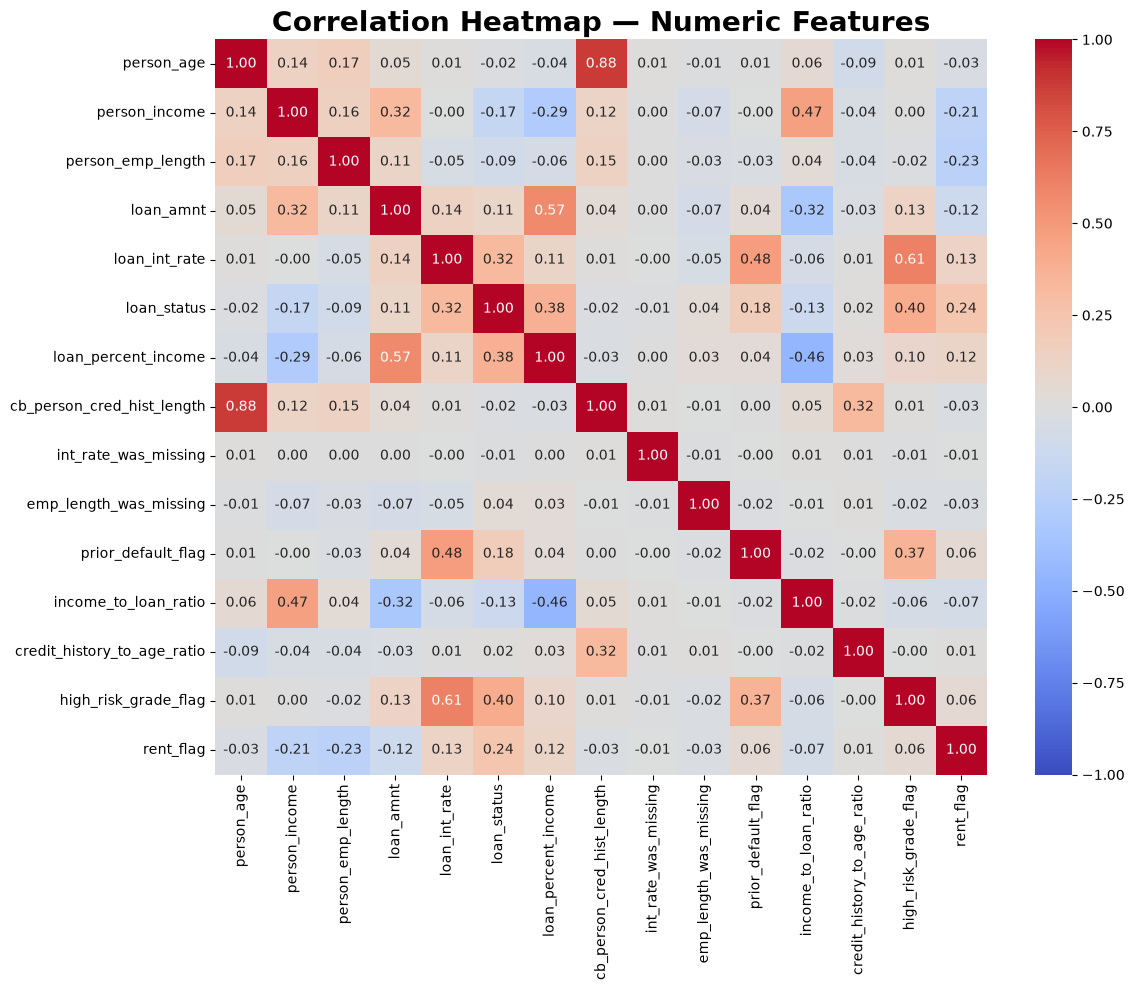

In [4]:
import seaborn as sns

plt.figure(figsize=(12, 10))
sns.heatmap(df[num_cols_eda].corr(), annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt='.2f')
plt.title('Correlation Heatmap — Numeric Features', fontsize=20, fontweight='bold')
plt.tight_layout()
plt.show()

**Correlation heatmap findings**

---

- Strongest positive correlation with `loan_status`: `loan_int_rate`, `loan_percent_income`, `high_risk_grade_flag`
- `prior_default_flag` correlates weakly with `loan_status`. This does not follow intuition, since prior default is usually a strong predictor in credit scoring. Worth checking whether a tree-based model finds it more useful than this linear correlation suggests.
- `person_age` and `cb_person_cred_hist_length` show strong multicollinearity (~0.85) — As expected, since credit history length are influenced by age. Tree-based models handle this reasonably well, so it's noted but not treated as a problem to fix.
- `income_to_loan_ratio` and `loan_percent_income` are strongly negatively correlated (-0.46), as expected — they're near-inverses of each other by construction.

### **1.4 Distribution plots**

#### **1.4.1 High risk grade flag distribution plot**

Since `high_risk_grade_flag` had the strongest correlation with `loan_status` on the heatmap (0.40), a bar chart comparing default rate between the two groups can reflect whether high-risk grades really do default more often, and by how much.

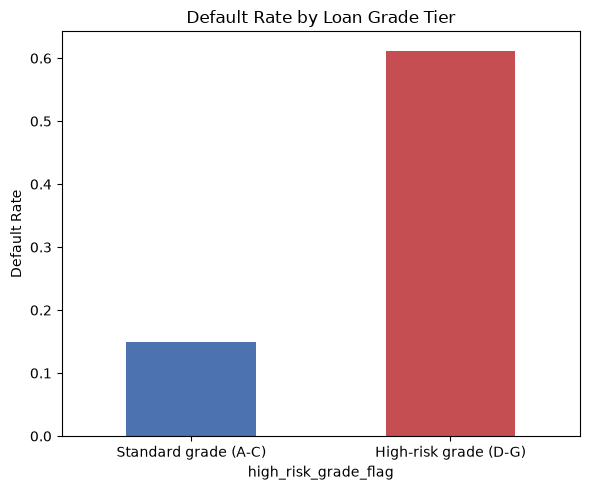

In [7]:
default_rate_by_grade = df.groupby('high_risk_grade_flag')['loan_status'].mean()

plt.figure(figsize=(6, 5))
default_rate_by_grade.plot(kind='bar', color=['#4C72B0', '#C44E52'])
plt.xticks([0, 1], ['Standard grade (A-C)', 'High-risk grade (D-G)'], rotation=0)
plt.ylabel('Default Rate')
plt.title('Default Rate by Loan Grade Tier')
plt.tight_layout()
plt.show()

#### **1.4.2 Loan percent income distribution plot**

The heatmap also showed `loan_percent_income` as one of the stronger predictors of default, a plot would be useful to understand how the distribution of loan-to-income burden differs between borrowers who defaulted and those who didn't.

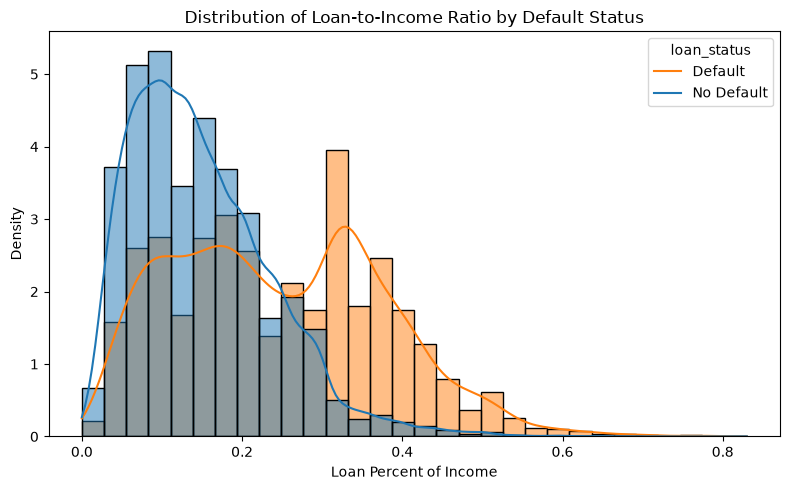

In [6]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='loan_percent_income', hue='loan_status', bins=30, kde=True, stat='density', common_norm=False)
plt.xlabel('Loan Percent of Income')
plt.ylabel('Density')
plt.title('Distribution of Loan-to-Income Ratio by Default Status')
plt.legend(title='loan_status', labels=['Default', 'No Default'])
plt.tight_layout()
plt.show()

### **1.5 Train-test split**

Convert categorical columns into numeric form, separate the target from the input features, and split into training and test sets.

In [ ]:
# Encode loan grade from 0 to 6 for A to G (ordinal encoding)
grade_order = {'A': 0, 'B': 1, 'C': 2, 'D': 3, 'E': 4, 'F': 5, 'G': 6}
df['loan_grade_ordinal'] = df['loan_grade'].map(grade_order)

# One-hot encode the remaining categoricals
cat_cols_dummies = [c for c in cat_cols if c != 'loan_grade']
X = pd.get_dummies(df.drop(columns=[target, 'loan_grade']), columns=cat_cols_dummies, drop_first=True)
y = df[target]
feature_names = X.columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scaled version for Logistic Regression
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

print(f"Train set: {X_train.shape[0]:,} rows | Test set: {X_test.shape[0]:,} rows")
print(f"Default rate — train: {y_train.mean():.2%} | test: {y_test.mean():.2%}")

Train set: 25,927 rows | Test set: 6,482 rows
Default rate — train: 21.87% | test: 21.88%


## **2. Decision Tree classifier**

### **2.1 Building a Decision Tree model**

In [37]:
tree_model = DecisionTreeClassifier(max_depth=4, random_state=42, class_weight='balanced')
tree_model.fit(X_train, y_train)

tree_train_acc = tree_model.score(X_train, y_train)
tree_test_acc = tree_model.score(X_test, y_test)
print(f"Decision Tree — train accuracy: {tree_train_acc:.3f} | test accuracy: {tree_test_acc:.3f}")

Decision Tree — train accuracy: 0.892 | test accuracy: 0.893


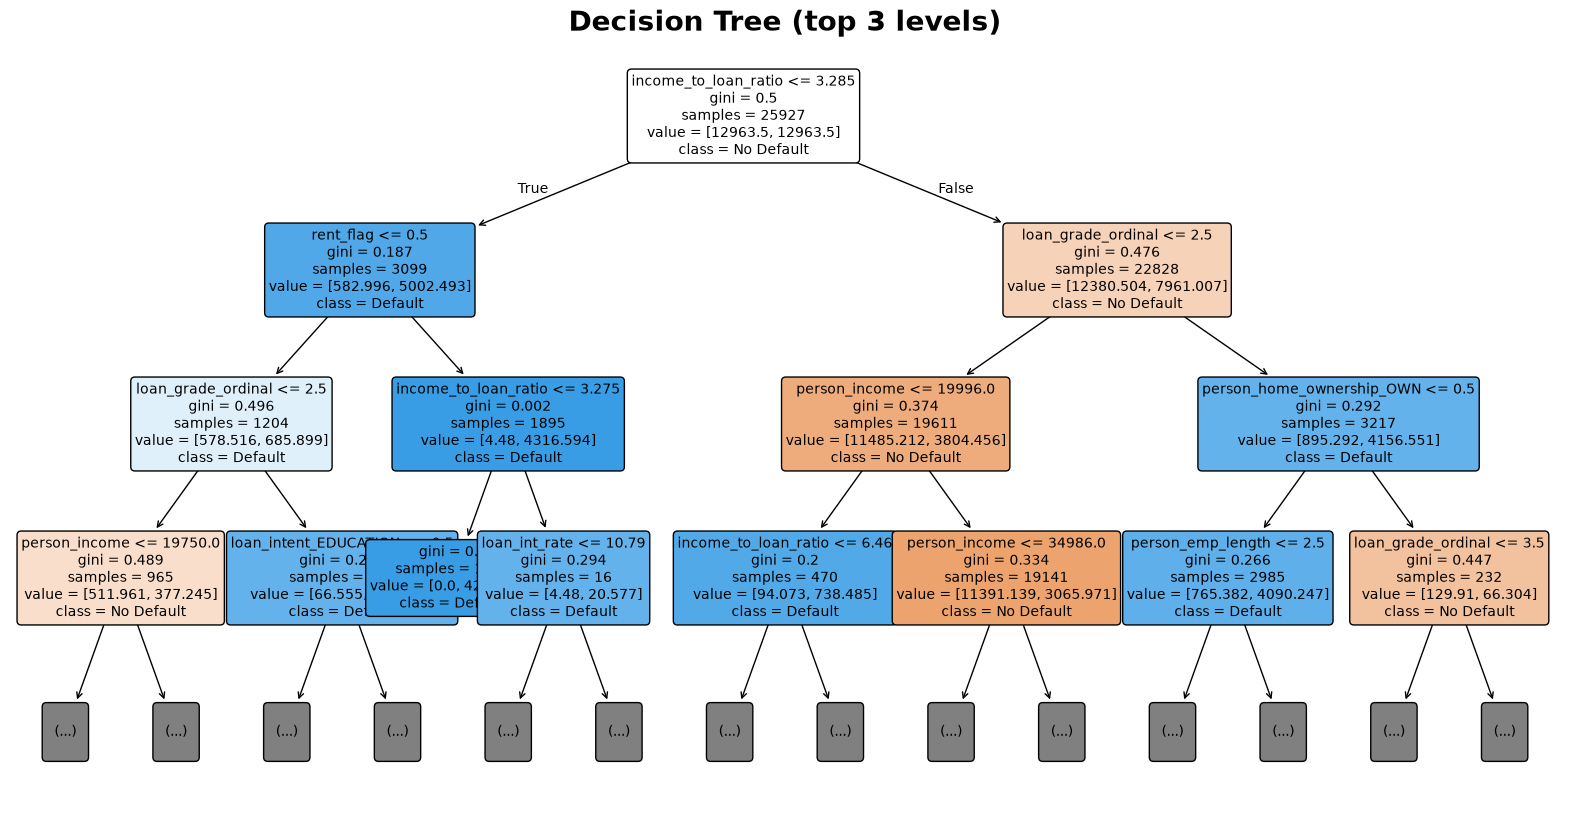

In [15]:
# Visualize the decision tree
plt.figure(figsize=(20, 10))
plot_tree(
    tree_model,
    feature_names=feature_names,
    class_names=['No Default', 'Default'],
    filled=True,
    rounded=True,
    fontsize=10,
    max_depth=3
)
plt.title("Decision Tree (top 3 levels)", fontsize=20, fontweight='bold')
plt.show()

### **2.2 Limitations of a single Decision Tree**

Single trees overfit as depth increases, and are unstable to small changes in training data.

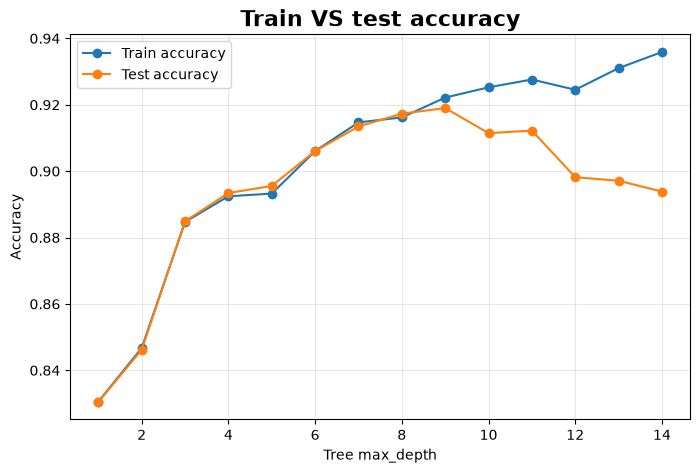

In [18]:
# Evaluate Decision Tree performance across different depths
depths = range(1, 15)
train_accs, test_accs = [], []

for d in depths:
    m = DecisionTreeClassifier(max_depth=d, random_state=42, class_weight='balanced')
    m.fit(X_train, y_train)
    train_accs.append(m.score(X_train, y_train))
    test_accs.append(m.score(X_test, y_test))

plt.figure(figsize=(8, 5))
plt.plot(depths, train_accs, marker='o', label='Train accuracy')
plt.plot(depths, test_accs, marker='o', label='Test accuracy')
plt.xlabel('Tree max_depth')
plt.ylabel('Accuracy')
plt.title('Train VS test accuracy', fontsize=16, fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

**Section 2 findings:** 

---

- The tree's very first split is `income_to_loan_ratio <= 3.285` — matches the strongest correlation from the heatmap. Second-level splits (`rent_flag`, `loan_grade_ordinal`) also line up with what the correlation analysis flagged. 
- Train and test accuracy track closely through depth ~8, then diverge 
- Test accuracy peaks around depth 9 (~92%) while train accuracy keeps climbing to ~93.6% by depth 14, with test accuracy actually falling to ~89.4% over the same range. 


## **3. Random forest classifier**

A Random Forest classifier is built to see whether it can outperform decision tree.

### **3.1 Building a Random Forest model**


In [36]:
forest_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)
forest_model.fit(X_train, y_train)

forest_train_acc = forest_model.score(X_train, y_train)
forest_test_acc = forest_model.score(X_test, y_test)
print(f"Random Forest — train accuracy: {forest_train_acc:.3f} | test accuracy: {forest_test_acc:.3f}")
print(f"(compare to Decision Tree — train: {tree_train_acc:.3f} | test: {tree_test_acc:.3f})")

Random Forest — train accuracy: 0.902 | test accuracy: 0.896
(compare to Decision Tree — train: 0.892 | test: 0.893)


### **3.2 Feature importance tree**

`feature_importances_` gives the average, across all trees, of how much each feature reduced impurity.

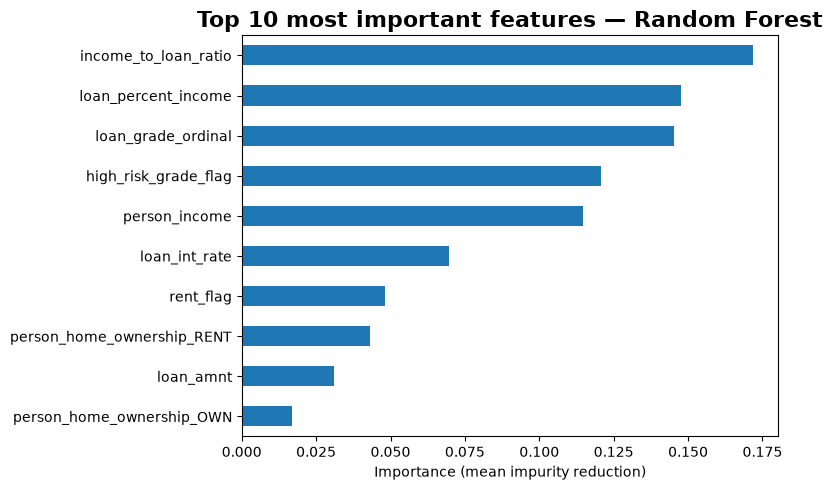

In [24]:
imp = pd.Series(forest_model.feature_importances_, index=feature_names)
top_features = imp.sort_values(ascending=False).head(10)

plt.figure(figsize=(8, 5))
top_features.sort_values().plot(kind='barh')
plt.xlabel('Importance (mean impurity reduction)')
plt.title('Top 10 most important features — Random Forest', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

**Section 3 findings:**

---

- Random Forest slightly beats Decision Tree on test accuracy (0.896 vs 0.893), but the overfitting gap doesn't meaningfully shrink - since `tree_model` was capped at depth 4. The depth curve in section 3 explains the slight advantage of Random Forest.

- Feature importance:
    - `income_to_loan_ratio`, `loan_percent_income`, and `loan_grade_ordinal` lead. 
    - `prior_default_flag` is not in the top 10, despite its non-linear potential
    - `rent_flag`/`person_home_ownership_RENT` and `high_risk_grade_flag`/`loan_grade_ordinal` split credit between overlapping signals.

## **4. Broader model comparison**

Two more models logistic Regression and Gradient Boosting are added for further comparison.

### **4.1 Building Logistic Regression model**

In Logistic Regression, coefficents are sensitive to feature scale, so `X_train_scaled` and `X_test_scaled` are used. 

In [26]:
logreg_model = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
logreg_model.fit(X_train_scaled, y_train)

logreg_train_acc = logreg_model.score(X_train_scaled, y_train)
logreg_test_acc = logreg_model.score(X_test_scaled, y_test)
print(f"Logistic Regression — train accuracy: {logreg_train_acc:.3f} | test accuracy: {logreg_test_acc:.3f}")

Logistic Regression — train accuracy: 0.815 | test accuracy: 0.810


### **4.2 Building Gradient Boosting model**

In [28]:

gb_model = GradientBoostingClassifier(random_state=42)
gb_model.fit(X_train, y_train)

gb_train_acc = gb_model.score(X_train, y_train)
gb_test_acc = gb_model.score(X_test, y_test)
print(f"Gradient Boosting — train accuracy: {gb_train_acc:.3f} | test accuracy: {gb_test_acc:.3f}")

Gradient Boosting — train accuracy: 0.925 | test accuracy: 0.926


### **4.3 Confusion matrix**

A confusion matrix shows exactly where the best model (Gradient Boosting) gets it wrong, and in which direction. 

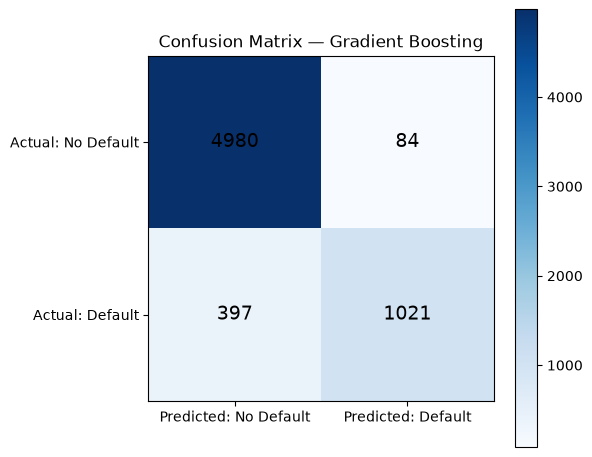

In [33]:
gb_pred = gb_model.predict(X_test)
cm = confusion_matrix(y_test, gb_pred)

plt.figure(figsize=(6, 5))
plt.imshow(cm, cmap='Blues')
plt.colorbar()
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha='center', va='center', fontsize=14)
plt.xticks([0, 1], ['Predicted: No Default', 'Predicted: Default'])
plt.yticks([0, 1], ['Actual: No Default', 'Actual: Default'])
plt.title('Confusion Matrix — Gradient Boosting')
plt.tight_layout()
plt.show()

### **4.4 Full comparison table**

Adding ROC-AUC and Average Precision gives a better picture across all four models rather than accuracy alone.

In [35]:
# Predicted probabilities for each model (tree models use unscaled X_test, logreg uses scaled)
tree_pd = tree_model.predict_proba(X_test)[:, 1]
forest_pd = forest_model.predict_proba(X_test)[:, 1]
logreg_pd = logreg_model.predict_proba(X_test_scaled)[:, 1]
gb_pd = gb_model.predict_proba(X_test)[:, 1]

comparison = pd.DataFrame({
    'Model': ['Decision Tree', 'Random Forest', 'Logistic Regression', 'Gradient Boosting'],
    'Accuracy': [tree_test_acc, forest_test_acc, logreg_test_acc, gb_test_acc],
    'ROC-AUC': [
        roc_auc_score(y_test, tree_pd),
        roc_auc_score(y_test, forest_pd),
        roc_auc_score(y_test, logreg_pd),
        roc_auc_score(y_test, gb_pd),
    ],
    'Avg Precision': [
        average_precision_score(y_test, tree_pd),
        average_precision_score(y_test, forest_pd),
        average_precision_score(y_test, logreg_pd),
        average_precision_score(y_test, gb_pd),
    ]
})
comparison

,Model,Accuracy,ROC-AUC,Avg Precision
0,Decision Tree,0.893397,0.877068,0.785756
1,Random Forest,0.895865,0.922257,0.868321
2,Logistic Regression,0.809935,0.872562,0.702717
3,Gradient Boosting,0.925795,0.930536,0.877547


**Section 4 findings:**

---

- Across all four models, Gradient Boosting wins on every metric — accuracy (0.926), ROC-AUC (0.931), Avg Precision (0.878). 
- Logistic Regression scores worst on every metric. Default risk here runs on sharp thresholds — like `income_to_loan_ratio <= 3.285` — which a linear model can't represent the way a tree naturally does.
- Gradient Boosting's confusion matrix shows 397 of 1,418 actual defaulters (~28%) missed, despite 92.6% overall accuracy — it doesn't support `class_weight='balanced'`, unlike the tree/forest models, so it never got the same imbalance correction. A clear illustration of why accuracy alone understates real-world risk.

Model selection:
- *Gradient Boosting* is used for Expected Loss (Section 5) and stress testing (Section 6), given it's the top performer across all three metrics.

## **5. Expected Loss**

Expected dollar loss per loan is given by the products of:

- **PD (Probability of Default)** — Gradient Boosting's predicted probability, straight from `predict_proba`.
- **LGD (Loss Given Default)** — what fraction of the loan is actually lost after any recovery. 55% was used in this case
- **EAD (Exposure At Default)** — money actually at risk, proxied by `loan_amnt`.


In [38]:
LGD_ASSUMPTION = 0.55

pd_hat = gb_model.predict_proba(X_test)[:, 1]

results = pd.DataFrame({
    'loan_amnt': df.loc[X_test.index, 'loan_amnt'].values,
    'PD': pd_hat,
})
results['LGD'] = LGD_ASSUMPTION
results['EAD'] = results['loan_amnt']
results['expected_loss'] = results['PD'] * results['LGD'] * results['EAD']

total_expected_loss = results['expected_loss'].sum()
total_exposure = results['EAD'].sum()

print(f"Test-set portfolio size: {len(results):,} loans")
print(f"Total exposure (EAD):     ${total_exposure:,.0f}")
print(f"Total expected loss:      ${total_expected_loss:,.0f}")
print(f"Expected loss as % of exposure: {total_expected_loss / total_exposure:.2%}")

results.sort_values('expected_loss', ascending=False).head(10)

Test-set portfolio size: 6,482 loans
Total exposure (EAD):     $62,453,275
Total expected loss:      $8,526,489
Expected loss as % of exposure: 13.65%


,loan_amnt,PD,LGD,EAD,expected_loss
3303,35000,0.992099,0.55,35000,19097.912503
3861,35000,0.967809,0.55,35000,18630.332377
4108,35000,0.966491,0.55,35000,18604.942702
2489,35000,0.962512,0.55,35000,18528.359581
2709,35000,0.958391,0.55,35000,18449.018848
3493,35000,0.951498,0.55,35000,18316.336858
1462,35000,0.949998,0.55,35000,18287.465843
6399,33950,0.952749,0.55,33950,17790.205963
5146,30000,0.982636,0.55,30000,16213.486173
957,35000,0.841277,0.55,35000,16194.576318


**Section 5 Findings**

---

- $8.53M expected loss on $62.45M total exposure (13.65%). 
- Given the actual test-set default rate is 21.88%; multiplied by the 55% LGD assumption gives ~12.0%, close to the model's 13.65% — the gap reflects the model's predicted probabilities not perfectly matching the true base rate, which is expected.

## **6. Stress testing**

In this section, different extreme scenarios are tested to see whether the model fails udner these circumstances.

In [ ]:
X_stressed = X_test.copy()

# Worsen income-related features by 20% in the risk-increasing direction
X_stressed['person_income'] = X_stressed['person_income'] * 0.8   
if 'loan_percent_income' in X_stressed.columns:
    X_stressed['loan_percent_income'] = X_stressed['loan_percent_income'] * 1.2   
if 'income_to_loan_ratio' in X_stressed.columns:
    X_stressed['income_to_loan_ratio'] = X_stressed['income_to_loan_ratio'] * 0.8   

pd_hat_stressed = gb_model.predict_proba(X_stressed)[:, 1] 

results['PD_stressed'] = pd_hat_stressed
results['expected_loss_stressed'] = results['PD_stressed'] * results['LGD'] * results['EAD']

total_el_base = total_expected_loss
total_el_stressed = results['expected_loss_stressed'].sum()
pct_increase = (total_el_stressed - total_el_base) / total_el_base

print(f"Base-case expected loss:      ${total_el_base:,.0f}")
print(f"Stressed expected loss:       ${total_el_stressed:,.0f}")
print(f"Increase under stress:        ${total_el_stressed - total_el_base:,.0f}  ({pct_increase:+.1%})")

Base-case expected loss:      $8,526,489
Stressed expected loss:       $11,123,662
Increase under stress:        $2,597,173  (+30.5%)


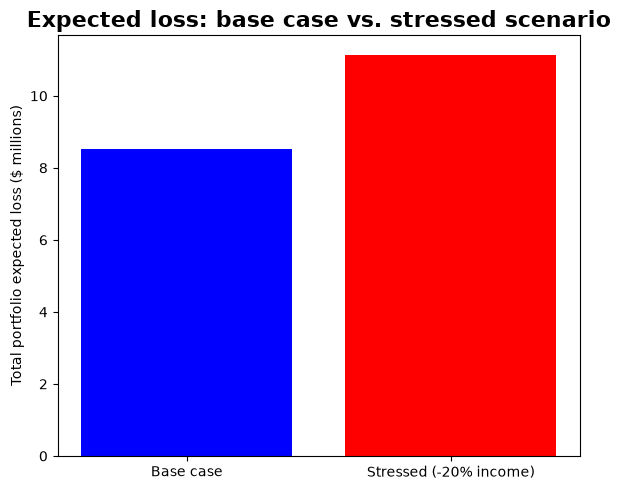

In [45]:
plt.figure(figsize=(6, 5))
plt.bar(['Base case', 'Stressed (-20% income)'], [total_el_base/1e6, total_el_stressed/1e6],
        color=['BLUE', 'RED'])
plt.ylabel('Total portfolio expected loss ($ millions)')
plt.title('Expected loss: base case vs. stressed scenario', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

**Section 6 findings**

---

- A 20% income drop increases expected loss by 30.5% ($8.53M VS $11.12M) — a disproportionate response to the size of the shock.
- This fits with Gradient Boosting being a non-linear model: borrowers sitting close to a risk threshold the model learned (like the `income_to_loan_ratio <= 3.285` split from Section 2) can get pushed across it by a moderate shock, amplifying the loss increase beyond a simple proportional response.

## **Section 7: Model Evaluation**

The target is imbalanced — a model that always predicts "no default" would score ~78% accuracy while catching zero actual defaulters. That's why ROC-AUC are used alongside accuracy throughout this notebook, not accuracy alone

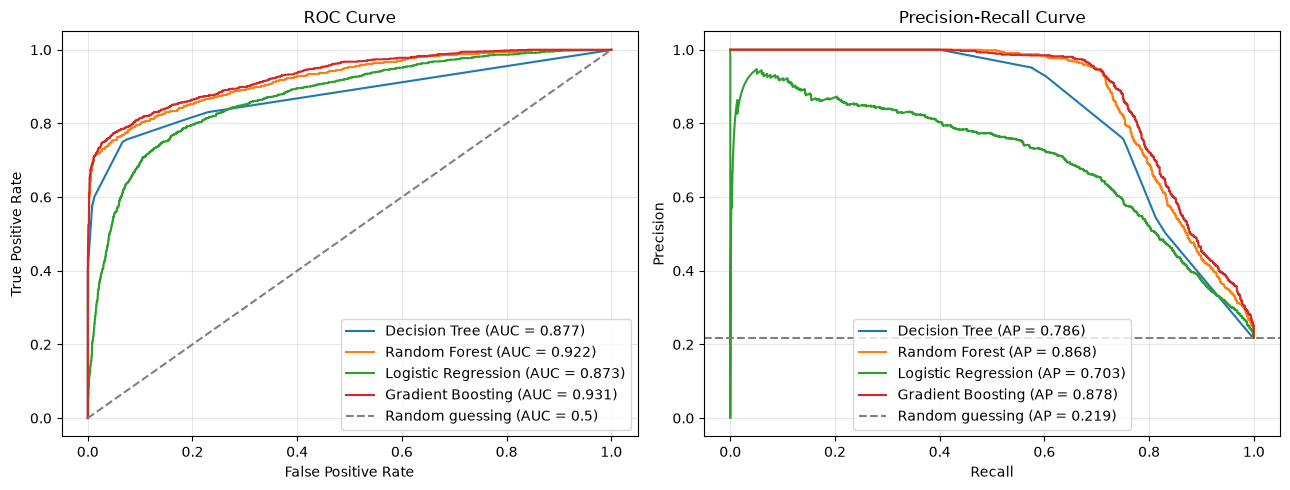

In [52]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

models_probs = {
    'Decision Tree': tree_pd,
    'Random Forest': forest_pd,
    'Logistic Regression': logreg_pd,
    'Gradient Boosting': gb_pd
}

# Plot ROC curves for each model
for name, probs in models_probs.items():
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc = roc_auc_score(y_test, probs)
    axes[0].plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})")
axes[0].plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random guessing (AUC = 0.5)')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve')
axes[0].legend()
axes[0].grid(alpha=0.3)


# Plot Precision-Recall curves for each model
for name, probs in models_probs.items():
    precision, recall, _ = precision_recall_curve(y_test, probs)
    ap = average_precision_score(y_test, probs)
    axes[1].plot(recall, precision, label=f"{name} (AP = {ap:.3f})")
baseline = y_test.mean()
axes[1].axhline(baseline, linestyle='--', color='gray', label=f'Random guessing (AP = {baseline:.3f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

**Section 7 findings**

---

- From both ROC curve and precision-recall curve, Gradient Boosting performs the best, whilst Logistic Regression scores the worst. The gap becomes wider in Precision-Recall curve, as Logistic Regression tend not to work well in a non linear relationship.
- Given the data is imbalanced (78/22), Precision-Recall Curve gives a better picture on how each model performed. 
- Logistic Regression's line fluctuates heavily at low recall (0-0.2) on the Precision-Recall curve. This suggests that it is the least reliable model compared to others.

## **Summary**

This project involves data cleaning and feature engineering in SQL, and evaluated 4 models, calculated expected loss, stress testing in this notebook. 

**Summary of findings**

---

- Gradient Boosting had the best performance on every metric (0.926 accuracy, 0.931 ROC-AUC), while Logistic Regression scored worst across the board — consistent with default risk here being driven by non-linear thresholds.
- A single Decision Tree overfits badly past depth 9, with test accuracy getting worse as the tree grew deeper. Random Forest (depth 8) and Gradient Boosting didn't show that collapse, despite comparable or greater complexity — direct evidence ensembling fixes the problem.
- Several SQL-engineered features proved genuinely useful: `income_to_loan_ratio`, `loan_percent_income`, and `loan_grade_ordinal` all ranked among Gradient Boosting's top predictors. However, `prior_default_flag` wasn't as useful as expected — both correlation and feature importance stayed weak.
- Using Gradient Boosting's predicted probabilities, base-case expected loss came to $8.53M — 13.65% of total exposure ($62.45M).
- A 20% income shock pushed expected loss to $11.12M, a 30.5% increase — disproportionate to the size of the shock, further evidence of the non-linear relationships driving these predictions.


**Limitation**

---

- LGD and EAD were assumptions as no recovery or collateral data existed in the dataset to estimate loss-given-default more precisely.
- Gradient Boosting doesn't support `class_weight='balanced'`, since the data itself was imbalanced — the confusion matrix showed it misses ~28% of actual defaulters despite high accuracy.
- 20% income shock was not based on any macroeconomic models or real scenarios. A more realistic approximation may require some macroeconomic models to support. 